**NLP?**
Is a field that combines linguistics and AI to enable computers to process and understand human language.

**SECTION 1: NLP Flow / BluePrint**

1. **Import the Libraries/Modules**
* Purpose: Import the important libraries that will help to accomplish the goal
* Key term:
    * Module: a library of important code that you can reuse in other programs.

2. **Data Collection, Cleaning, and Exploraion**
* Purpose: Get the data (e.g., SMS messages).
* Key term:
    * Dataset: A collection of data.

3. **Text Cleaning (Normalization)**
* Purpose: Make text consistent and remove unnecessary variation.
* What we do:
    * Convert all text to Lowercase text ("Hello" → "hello")
    * Remove punctuation
* Key terms:
    * Normalization: Making text uniform so the model doesn’t treat similar things differently.

4. **Tokenization**
* Purpose: Break text into smaller pieces (words).
    * Example:
        "I love AI" → ["I", "love", "AI"]
* Key term: 
    * Token: A single unit (usually a word).

5. **Stop Words Removal**
* Purpose: Remove common words that don’t add much meaning.
    * Example: "the", "is", "and"
* Key term:
    * Stop words: Frequently used words that carry little useful information.

6. **Stemming / Lemmatization** 
* Purpose: Reduce words to their base form.
    * Example:
        * Stemming: "running" → "run"
        * Lemmatization: "better" → "good"
* Key terms:
    * Stem: Crude root form of a word
    * Lemma: Proper dictionary form of a word

7. **Vectorization**
* Purpose: Convert text into numbers so a model can understand it.
    * Example:
        "love AI" → [0,1,1,0]
* Key terms:
    * Vector: A list of numbers
    * Bag of Words: Count of words, ignoring order
    * Feature: A word used as input to the model

8. **Model Training**
* Purpose: Teach a machine learning model to recognize patterns.
    * Example: Learn what spam messages look like.
* Key terms:
    * Model: A function that learns from data
    * Training: The process of learning patterns

9. **Prediction / Evaluation**
* Purpose: Test how well the model performs.
    * Example: Predict if a new SMS is spam or ham.
* Key terms:
    * Prediction: Model output
    * Accuracy: How often the model is correct

### 1. Import the Libraries / Modules, that will help achieve the desired goal

In [95]:
# import the base libraries for loading data and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#view the graphs inline
%matplotlib inline              

# We will use the industry standard lib
import spacy

# import the sklearn functions useful for NLP
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline



#### 2. Data Collection And Exploration

In [47]:
# Load the data
sms_data = pd.read_csv('../datasets/spam.csv', encoding='latin-1')

In [48]:
# View the first 5 columns
sms_data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


**Observations**
The data has the label column named as v1 and the features column as v2. The rest of the columns will not contribute mutch to our goal as they are unnamed and seem to contain missing values (more on this later)

Lets explore the data next (Note: in the future, use the info() function to get the data info all at once))


In [ ]:
# View the shape of the data -> total rows and columns i.e, (rows, columns)
print("The summary of the data is as follows:", "\n",
         sms_data.info(), "\n", "The shape of the data is: ", sms_data.shape, "\n", 
      "The total missing values per column is: ", sms_data.isna().sum(), "\n",
       "The data types for each column","\n", 
       sms_data.dtypes, "\n"
        )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   int64 
 1   message  5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB
The summary of the data is as follows: 
 None 
 The shape of the data is:  (5572, 2) 
 The total missing values per column is:  label      0
message    0
dtype: int64 
 The data types for each column 
 label       int64
message    object
dtype: object 
 Check for duplicates:  403


#

In the future, use the info() function to get the summary as quickly as possible

* The Unnamed columns have many missing values and will not contribute to the goal of this project and will be removed. V2 and v1 columns have no missing values and will be kept.

In [49]:
# remove the unneccesary columns and rename the remaining columns to something meaningful
sms_data = sms_data[['v1', 'v2']]
sms_data.columns = ['label', 'message']
sms_data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Since our goal is to classify the messages, lets convert the labels: ham = 0 and spam = 1 

In [50]:
# convert the label column to binary values
sms_data['label'] = sms_data['label'].map({'ham': 0, 'spam': 1})
# verify
sms_data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
#Check for number of dupplicates
print("Number of duplicates: ", sms_data.duplicated().sum())

# View the top 10 duplicates, sort them so that duplicates are together. Note "keep=False" -
# makes sure we return both the 1st and 2nd duplicate. 
sms_data[sms_data['message'].duplicated(keep=False)].sort_values(by='message').head(10)


Number of duplicates:  403


,label,message
504,1,+123 Congratulations - in this week's competit...
2123,1,+123 Congratulations - in this week's competit...
2343,0,1) Go to write msg 2) Put on Dictionary mode 3...
1372,0,1) Go to write msg 2) Put on Dictionary mode 3...
2162,0,1) Go to write msg 2) Put on Dictionary mode 3...
1049,1,18 days to Euro2004 kickoff! U will be kept in...
2718,1,18 days to Euro2004 kickoff! U will be kept in...
2043,1,4mths half price Orange line rental & latest c...
388,1,4mths half price Orange line rental & latest c...
1778,0,7 wonders in My WORLD 7th You 6th Ur style 5th...


**Dealing with Duplicates**
* Impact of duplicates on the goal: 
* Resolution: 

In [51]:
# Remove the duplicates 
sms_data = sms_data.drop_duplicates()

#verify the removal
sms_data[sms_data['message'].duplicated(keep=False)].sort_values(by='message').head(10)


,label,message


The count of Spam and ham rows from the data
label
0    4516
1     653
Name: count, dtype: int64


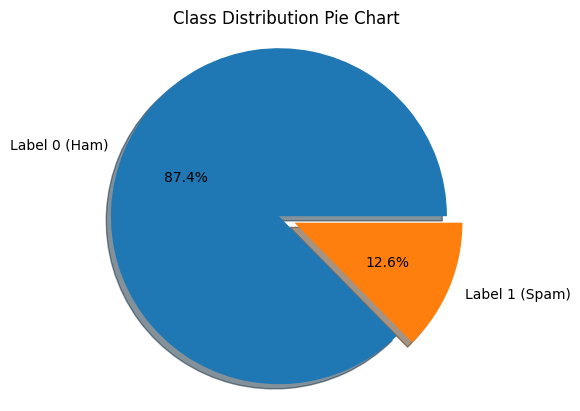

In [7]:
#Check the class Distribution -> Check the data balance, you dont want 
# a certain feature to have more examples than the other as this will cause
# the model to learn those features only. 
print("The count of Spam and ham rows from the data")
print(sms_data['label'].value_counts())

# make sense of the info in a pie chart
explode = (0.1,0)
plt.pie(sms_data['label'].value_counts(), explode = explode,
        labels=['Label 0 (Ham)', 'Label 1 (Spam)'], 
        autopct='%1.1f%%', shadow=True)
plt.axis('equal')
plt.title("Class Distribution Pie Chart")
plt.show()


From the class distribution, we have roughly 87% ham and 13%spam. If we continue with the data as it is, it will influence the model to overfit the data, and especially when it comes to detecting spam -- as there isn't enough examples for spam especially when we will split the data for training and testing. 
* Imbalance means the model sees one class much more, it becomes biased toward it.

There are some techniques we can employ to address the issue which fall into two stages, Pre-Training and Post-Training:
* Pre-Training: This is where we deal with the issue before training the model using techniques such as oversampling.
    * **Oversampling** - the idea is to duplicate the imbalanced variable (spam messages) to balance the data.
    * **Undersampling** - downsize the other variable(s) (ham messages) to match the imbalanced one
    * Apply the **SMOTE** technique - this technique helps us with generating synthetic examples(data) for the imbalanced data. This technique is *applied after splitting the data into training and test set*. SMOTE creates new minority samples by interpolating between similar existing ones, not by copying, hence it can work but is not always ideal for NLP, because SMOTE works best with continuous numeric data, NLP vectors are sparse and discrete.
    * Use **Class Weights**: Simply tell the model which variable is more important. Note that Naive Bayes doesnt directly support class weights, but other models do.
    * Apply a **Text Augmentation Technique**: With help from libraries such as nlpaug, EDA, and TextAttack, to name a few, we can augment the data. So instead of duplicating or reducing the data, or creating fake numeric vectors, we create new text samples by slightly modifying real text. 
        * Consider the sentence "win a free prize now". It can be augmented into one of the following: "win a free reward now", "get a free prize now", and "win a free prize today".
        * Augmentation techniques include synonym replacement, contextual augmentation, random insertion, random swap, and random deletion to name a few.
* Post-Training: This is where we deal with the issue after or during the training of the model using better evaluation metrics.
    * Precision → “When I predict spam, how often am I right?”
    * Recall → “How many spam messages did I catch?”
    * F1-score → Balance of both -> did I classify both spam and ham correctly?

All these methods for dealing with the imbalanced data can be explored and one can determine how they impact the model's performance. I will proceed with the nlpaug library to generate meaningful data with real sentences by applying contextual augmentation to take advantage of the recent powerful tech -- Why not?!


In [52]:
# import the nlpaug contextual augmenter
import nlpaug.augmenter.word as naw

In [53]:
# initialize the augmenter. We will use the bert-based-uncased pre-trained model
# to replace(substitute) words
aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action='substitute')

In [54]:
# apply only to the spam features (separate spam and ham)
spam_df = sms_data[sms_data['label'] == 1]
ham_df = sms_data[sms_data['label'] == 0]

In [55]:
# Create a function to apply the augmentation with a fallback logic if augmentation fails
def augment_data(text):
    try:
        return aug.augment(text)
    except:
        return text

#create the augmented samples
spam_df['augmented'] = spam_df['message'].apply(augment_data)

In [56]:
# assess
print(spam_df.info())
spam_df.head()

<class 'pandas.DataFrame'>
Index: 653 entries, 2 to 5567
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      653 non-null    int64 
 1   message    653 non-null    str   
 2   augmented  653 non-null    object
dtypes: int64(1), object(1), str(1)
memory usage: 20.4+ KB
None


,label,message,augmented
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,[one player from 2 a wkly comp to win league c...
5,1,FreeMsg Hey there darling it's been 3 week's n...,[freemsg hey there darling that's just 3 minut...
8,1,WINNER!! As a valued network customer you have...,[bingo!! finding a valued single customer you ...
9,1,Had your mobile 11 months or more? U R entitle...,[had our job 11 months or more? your r entitle...
11,1,"SIX chances to win CASH! From 100 to 20,000 po...","[six percent is get cash! from 100 for 20, plu..."


In [57]:
# Create a dataframe from the augmented set
aug_spam_df = spam_df.copy()
aug_spam_df['message'] = aug_spam_df['augmented']

# Combine with the original data
sms_augmented = pd.concat([ham_df, spam_df[['label', 'message']], aug_spam_df[['label', 'message']]])

# verify
sms_augmented.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
6,0,Even my brother is not like to speak with me. ...


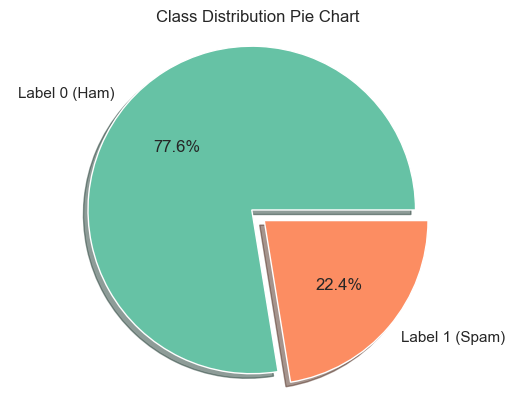

In [88]:
# make sense of the info in a pie chart again
explode = (0.1,0)
plt.pie(sms_augmented['label'].value_counts(), explode = explode,
        labels=['Label 0 (Ham)', 'Label 1 (Spam)'], 
        autopct='%1.1f%%', shadow=True)
plt.axis('equal')
plt.title("Class Distribution Pie Chart")
plt.show()

In [58]:
# Save the data to avoid repeating some steps above that take longer to augment the data
sms_augmented.to_csv('../datasets/sms_messages_v2', index = False)

In [59]:
# Load the new data to continue from here if the kernel restarted or pc crashed
# uncomment the line below to load the data
sms_aug = pd.read_csv('../datasets/sms_messages_v2', encoding='latin-1')

In [60]:
# data info
sms_aug.info()
sms_aug.head()

<class 'pandas.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5822 non-null   int64
 1   message  5822 non-null   str  
dtypes: int64(1), str(1)
memory usage: 91.1 KB


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,0,U dun say so early hor... U c already then say...
3,0,"Nah I don't think he goes to usf, he lives aro..."
4,0,Even my brother is not like to speak with me. ...


The dataset is still not balanced, with about 10% improvement for the spam data. We will deal with this problem later when we implement the model.
Lets understand the data a bit more:

    * We need to know what distinguishes spam from ham in terms of features. This may allow us to come up with even more features that will allow us to train a good model.

    * Spam : a message that seems suspicious, convincing and too good to be true. Usually include currencies, URL's, prizes, words like "Congratulations", and the text is usually longer. These type of messages usually aim to get the user to perform a task for a reward.

    * Ham : a normal message without any intention to guide the user to perform a certain task for a reward.

So we will analyse the data for word counts, word frequency, sentence length, URLs', phone numbers etc. These are features that can help us understand the data better and guide our model selection decisions

In [ ]:
# Add features: character length, word count, whether or not the message has 
# numbers(currency), wheteher or not a URL is present

sms_aug['char_length'] = sms_aug['message'].apply(len)
sms_aug['word_count'] = sms_aug['message'].apply(lambda x: len(x.split()))

#check if a message has a url and numbers (currency, phone numbers) using regex
import re

def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

def has_meaningful_numbers(text):
    text = remove_urls(text)
    return bool(re.search(r'\d{3,}(\.\d+)?', text))
# apply to the augmented data 
sms_aug['has_number'] = sms_aug['message'].apply(has_meaningful_numbers)
sms_aug['has_number'] = sms_aug['message'].apply(has_meaningful_numbers).astype(int)



# create the has_url column
def has_url(text):
    pattern = r'http[s]?://|www\.'
    return 1 if re.search(pattern, text) else 0

sms_aug['has_url'] = sms_aug['message'].apply(has_url)


# verify
sms_aug.info()
sms_aug.head()


<class 'pandas.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   label        5822 non-null   int64
 1   message      5822 non-null   str  
 2   char_length  5822 non-null   int64
 3   word_count   5822 non-null   int64
 4   has_number   5822 non-null   int64
 5   has_url      5822 non-null   int64
dtypes: int64(5), str(1)
memory usage: 273.0 KB


,label,message,char_length,word_count,has_number,has_url
0,0,"Go until jurong point, crazy.. Available only ...",111,20,0,0
1,0,Ok lar... Joking wif u oni...,29,6,0,0
2,0,U dun say so early hor... U c already then say...,49,11,0,0
3,0,"Nah I don't think he goes to usf, he lives aro...",61,13,0,0
4,0,Even my brother is not like to speak with me. ...,77,16,0,0


In [ ]:
sms_aug['has_number'].value_counts()

has_number
0    4765
1    1057
Name: count, dtype: int64

The function above to check for the numbers has been created to search atleast 3 digits in a row including those with a decimal. This is so that we check for currency accurately, as a lot of spam contains currency and phone numbers, excluding numbers in urls.

In [78]:
# Our next goal is to view the common words for each message type. 1st The data has to be 
# cleaned by removing the stop words.
# =======================================

# Use the Spacy library for this purpose as it is more accurate and modern. 
# It is context aware and handles grammar better
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    # Handle bad inputs
    if not isinstance(text, str):
        text = str(text)

    doc = nlp(text.lower())

    words= [
            token.lemma_
            for token in doc 
            if token.is_alpha and not token.is_stop
        ]
    return " ".join(words)

# Apply preprocessing
sms_aug['clean_message'] = sms_aug['message'].apply(preprocess)

#lets keep only the meaningful columns
sms_aug = sms_aug[['label', 'clean_message', 'char_length',
                    'word_count','has_number', 'has_url']]
# Verify
sms_aug.info()
sms_aug.head()


<class 'pandas.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   label          5822 non-null   int64
 1   clean_message  5822 non-null   str  
 2   char_length    5822 non-null   int64
 3   word_count     5822 non-null   int64
 4   has_number     5822 non-null   int64
 5   has_url        5822 non-null   int64
dtypes: int64(5), str(1)
memory usage: 273.0 KB


,label,clean_message,char_length,word_count,has_number,has_url
0,0,jurong point crazy available bugis n great wor...,111,20,0,0
1,0,ok lar joke wif u oni,29,6,0,0
2,0,u dun early hor u c,49,11,0,0
3,0,nah think go usf live,61,13,0,0
4,0,brother like speak treat like aids patent,77,16,0,0


In [37]:
# View the common words

from collections import Counter

# Join all spam messages into one string, then split
spam_text = " ".join(sms_augmented[sms_augmented['label'] == 1]['clean_message'])
spam_words = spam_text.split()

# Same for ham
ham_text = " ".join(sms_augmented[sms_augmented['label'] == 0]['clean_message'])
ham_words = ham_text.split()

# Get most common words
print(Counter(spam_words).most_common(10))
print(Counter(ham_words).most_common(10))

[('call', 554), ('free', 322), ('2', 309), ('text', 228), ('txt', 225), ('u', 222), ('mobil', 208), ('4', 192), ('ur', 183), ('stop', 182)]
[('u', 883), ('go', 404), ('get', 349), ('gt', 288), ('lt', 287), ('2', 284), ('come', 275), ('got', 236), ('know', 236), ('like', 234)]


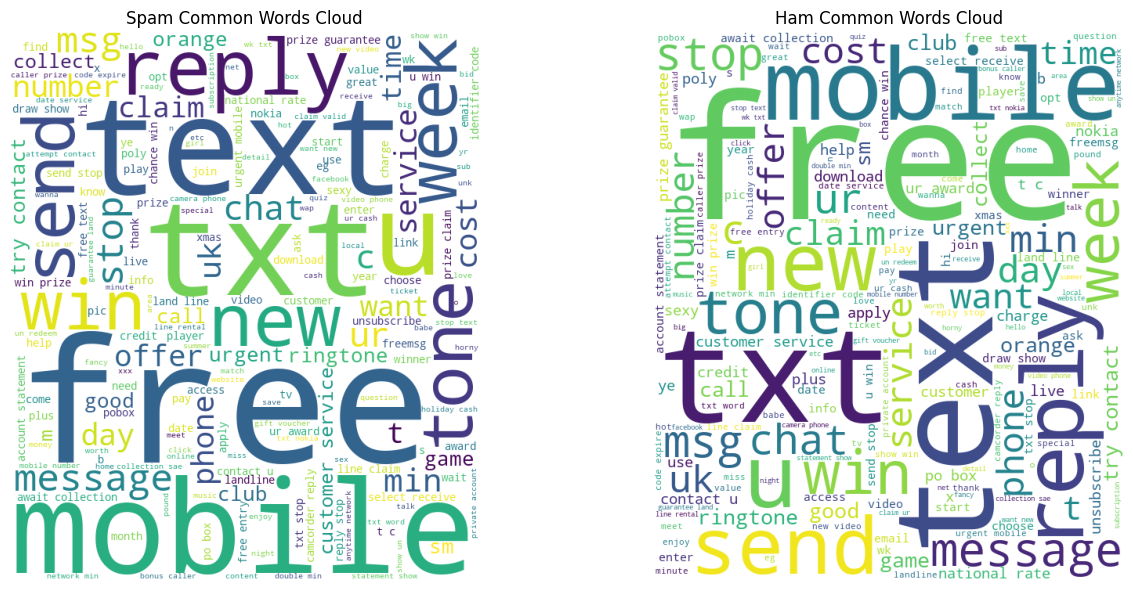

In [80]:
# Visualize the common words without stop words.
# ===================
# import the wordcloud lib
from wordcloud import WordCloud

# Create the wordcloud visual for both spam and ham
# ======================
# create data with spam only
spam_text = " ".join(sms_aug[sms_aug['label'] == 1]['clean_message'])


# create data with ham only
ham_text = " ".join(sms_aug[sms_aug['label'] == 0]['clean_message'])

# create wordcloud charts for each
spam_wc = WordCloud(width = 600, height=700, 
                    background_color='white').generate(spam_text)
ham_wc = WordCloud(width=600, height=700,
                    background_color='white').generate(spam_text)

# Create subplots
plt.figure(figsize=(14, 6), facecolor = None)

plt.subplot(1, 2, 1)
plt.imshow(spam_wc)
plt.axis("off")
plt.title("Spam Common Words Cloud")

plt.subplot(1, 2, 2)
plt.imshow(ham_wc)
plt.axis("off")
plt.title("Ham Common Words Cloud")

plt.tight_layout() 
plt.show()

From the word cloud we can indeed see the common words found in spam messages such as award, customer, win, free and so on.

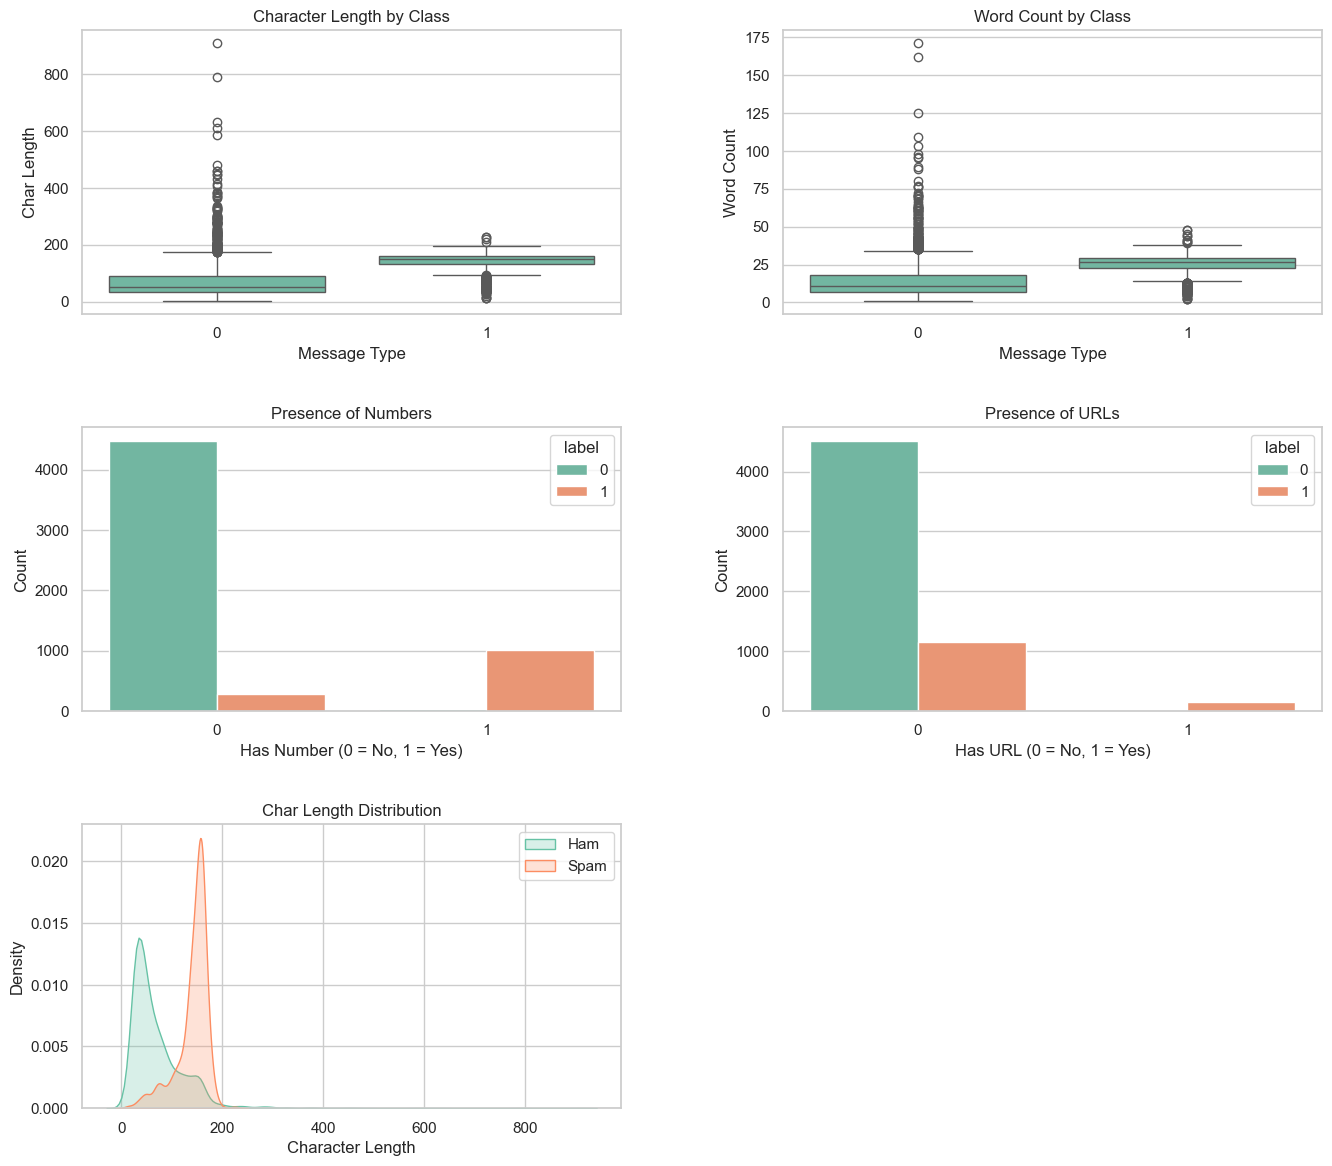

In [ ]:
# visualise from the created features
#=============================


# Theme + palette
sns.set_theme(style="whitegrid", palette="pastel")
sns.set_palette("Set2")

# Create figure with 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Character Length
sns.boxplot(data=sms_aug, x='label', y='char_length', ax=axes[0, 0])
axes[0, 0].set_title('Character Length by Class')
axes[0, 0].set_xlabel('Message Type')
axes[0, 0].set_ylabel('Char Length')

# 2. Word Count
sns.boxplot(data=sms_aug, x='label', y='word_count', ax=axes[0, 1])
axes[0, 1].set_title('Word Count by Class')
axes[0, 1].set_xlabel('Message Type')
axes[0, 1].set_ylabel('Word Count')

# 3. Has Number
sns.countplot(data=sms_aug, x='has_number', hue='label', ax=axes[1, 0])
axes[1, 0].set_title('Presence of Numbers')
axes[1, 0].set_xlabel('Has Number (0 = No, 1 = Yes)')
axes[1, 0].set_ylabel('Count')

# 4. Has URL
sns.countplot(data=sms_aug, x='has_url', hue='label', ax=axes[1, 1])
axes[1, 1].set_title('Presence of URLs')
axes[1, 1].set_xlabel('Has URL (0 = No, 1 = Yes)')
axes[1, 1].set_ylabel('Count')

# 5. Char Length Distribution (KDE)
sns.kdeplot(
    data=sms_aug[sms_aug['label'] == 0],
    x='char_length',
    label='Ham',
    fill=True,
    ax=axes[2, 0]
)
sns.kdeplot(
    data=sms_aug[sms_aug['label'] == 1],
    x='char_length',
    label='Spam',
    fill=True,
    ax=axes[2, 0]
)
axes[2, 0].set_title('Char Length Distribution')
axes[2, 0].set_xlabel('Character Length')
axes[2, 0].legend()

# 6. Remove last empty subplot (clean look)
fig.delaxes(axes[2, 1])

# Adjust spacing (key improvement)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

plt.show()


### 7. Vectorization And Model Training

In [ ]:
# instantiate the vectorizer
vectorizer = CountVectorizer()

# Define the feature and the target
X = sms_aug[['clean_message', 'char_length', 'word_count', 'has_number', 'has_url']]
Y = sms_aug['label']

# Split into test and training set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3,
                                                    random_state=42, stratify = Y)

# Preprocess the pipeline
text_features = 'clean_message'
numeric_features = ['char_length', 'word_count', 'has_number', 'has_url']

preprocessor = ColumnTransformer(transformers = [
    ('text', TfidfVectorizer(max_features=3000), text_features),
    ('num', StandardScaler(), numeric_features)
])

# Model creation: We use the class weight parameter because our data is not balanced. This lets the mode
# know which features it needs to pay attention to
model = Pipeline(steps=[('preprocessor', preprocessor),
                       ('classifier', LogisticRegression(class_weight='balanced', max_iter=300))])

# two functions to print the model metrics
def training_scores(y_test, y_pred):
    acc = round(accuracy_score(y_test, y_pred), 3)
    f1 = round(f1_score(y_test, y_pred), 3)
    cr = classification_report(y_test, y_pred)
    print(f'Training Scores: Accuracy={acc}')
    print("\n", "The classification report on Training set", "\n", cr)

def validation_scores(y_test, y_pred):
    acc = round(accuracy_score(y_test, y_pred), 3)
    f1 = round(f1_score(y_test, y_pred), 3)
    cr = classification_report(y_test, y_pred)
    print(f'Validation Scores: Accuracy={acc}')
    print("\n", "The classification report on Test set", "\n", cr)

# Train the Logistic Regression model and predict
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Evaluation Metrics For the Logistic Regression Model", "\n")
# Call the functions to evaluate the model on the training and test sets
training_scores(y_train, y_train_pred)
validation_scores(y_test, y_pred)



Evaluation Metrics For the Logistic Regression Model
Training Scores: Accuracy=0.977, F1-Score=0.949
The classification report on Test set 
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      3161
           1       0.95      0.95      0.95       914

    accuracy                           0.98      4075
   macro avg       0.97      0.97      0.97      4075
weighted avg       0.98      0.98      0.98      4075

Validation Scores: Accuracy=0.967, F1-Score=0.927
The classification report on Test set 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1355
           1       0.93      0.93      0.93       392

    accuracy                           0.97      1747
   macro avg       0.95      0.95      0.95      1747
weighted avg       0.97      0.97      0.97      1747



In [100]:
# Training a Random Forest Classifier
rfc = Pipeline(steps=[('preprocessor', preprocessor),
                       ('classifier', RandomForestClassifier(class_weight='balanced'))])
rfc.fit(X_train, y_train)
y_train_pred = rfc.predict(X_train)
y_pred = rfc.predict(X_test)
print("Evaluation Metrics For the RandomForestClassifier Model")
# Call the functions to evaluate the model on the training and test sets
training_scores(y_train, y_train_pred)
validation_scores(y_test, y_pred)

Evaluation Metrics For the RandomForestClassifier Model
Training Scores: Accuracy=1.0, F1-Score=0.999
The classification report on Test set 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3161
           1       1.00      1.00      1.00       914

    accuracy                           1.00      4075
   macro avg       1.00      1.00      1.00      4075
weighted avg       1.00      1.00      1.00      4075

Validation Scores: Accuracy=0.979, F1-Score=0.952
The classification report on Test set 
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1355
           1       0.97      0.93      0.95       392

    accuracy                           0.98      1747
   macro avg       0.98      0.96      0.97      1747
weighted avg       0.98      0.98      0.98      1747



In [101]:
# XGB Model
xgb = Pipeline(steps=[('preprocessor', preprocessor),
                       ('classifier', XGBClassifier(class_weight='balanced'))])
xgb.fit(X_train, y_train)
y_train_pred = xgb.predict(X_train)
y_pred = xgb.predict(X_test)
print("Evaluation Metrics For the XGB Model")
# Call the functions to evaluate the model on the training and test sets
training_scores(y_train, y_train_pred)
validation_scores(y_test, y_pred)

c:\Users\Isaac Maake\Documents\Projects\AIE\Data-Science-AI-ML-\NLP\nlpEnv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:18:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluation Metrics For the XGB Model
Training Scores: Accuracy=0.992, F1-Score=0.982
The classification report on Test set 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      3161
           1       1.00      0.97      0.98       914

    accuracy                           0.99      4075
   macro avg       0.99      0.98      0.99      4075
weighted avg       0.99      0.99      0.99      4075

Validation Scores: Accuracy=0.975, F1-Score=0.942
The classification report on Test set 
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1355
           1       0.97      0.92      0.94       392

    accuracy                           0.97      1747
   macro avg       0.97      0.95      0.96      1747
weighted avg       0.97      0.97      0.97      1747



Conclusion